# Notebook 03: PINN for a Nonlinear Reaction-Diffusion PDE

This notebook solves the one-dimensional Fisher-KPP equation

$$
u_t = D u_{xx} + r u(1-u), \qquad x \in [0,1], \ t \in [0,T]
$$

with a space-time PINN and compares it against a finite-difference reference solution.


## Why this is a natural PINN problem

- The task is to solve a **nonlinear PDE directly in space-time**.
- The unknown is the state field `u(x,t)`, not a control law.
- HJB/PMP are not the natural framework because there is no underlying optimal control problem to solve.


In [1]:
from pathlib import Path
import sys
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import solve_bvp, solve_ivp
from scipy.interpolate import RegularGridInterpolator
from tqdm.auto import trange


ROOT = Path(r"e:/Optimal_Control/PINN/hjb_pinn_exoskeleton")
if not ROOT.exists():
    ROOT = Path.cwd().resolve()
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils import set_global_seed, get_device

set_global_seed(42)
device = get_device()
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams["figure.dpi"] = 140
NOTEBOOK_NAME = "03_pinn_nonlinear_reaction_diffusion"
OUTDIR = ROOT / "notebooks" / "debug_outputs" / NOTEBOOK_NAME
OUTDIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name: str):
    fig.tight_layout()
    fig.savefig(OUTDIR / name, bbox_inches="tight")

print("device:", device)

device: cpu


c:\Users\Mohammad Belal\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
D = 0.01
R = 2.0
T_FINAL = 0.5
NX = 201
DX = 1.0 / (NX - 1)
DT = 5e-4
NT = int(T_FINAL / DT) + 1
X = np.linspace(0.0, 1.0, NX)
T_GRID = np.linspace(0.0, T_FINAL, NT)

def initial_condition(x):
    return 0.35 * np.exp(-60.0 * (x - 0.35) ** 2)

u_ref = np.zeros((NT, NX), dtype=np.float64)
u_ref[0] = initial_condition(X)
for n in range(NT - 1):
    u = u_ref[n]
    lap = (u[2:] - 2.0 * u[1:-1] + u[:-2]) / (DX ** 2)
    react = R * u[1:-1] * (1.0 - u[1:-1])
    u_next = u.copy()
    u_next[1:-1] = u[1:-1] + DT * (D * lap + react)
    u_next[0] = 0.0
    u_next[-1] = 0.0
    u_ref[n + 1] = np.clip(u_next, 0.0, 1.2)

class FisherPINN(nn.Module):
    def __init__(self, hidden_width=64, hidden_depth=4):
        super().__init__()
        layers = [nn.Linear(2, hidden_width), nn.Tanh()]
        for _ in range(hidden_depth - 1):
            layers += [nn.Linear(hidden_width, hidden_width), nn.Tanh()]
        layers.append(nn.Linear(hidden_width, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

def fisher_terms(model, x, t):
    u = model(x, t)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    residual = u_t - D * u_xx - R * u * (1.0 - u)
    return u, residual

## Train a space-time PINN

The loss includes the PDE residual, two Dirichlet boundaries, and the smooth initial condition.


In [3]:
model = FisherPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 3500
history = {"total": [], "pde": [], "bc": [], "ic": []}

for epoch in trange(epochs, desc="Training Fisher-KPP PINN"):
    optimizer.zero_grad()

    x_f = torch.rand(4000, 1, device=device, requires_grad=True)
    t_f = T_FINAL * torch.rand(4000, 1, device=device, requires_grad=True)
    _, residual = fisher_terms(model, x_f, t_f)
    loss_pde = (residual ** 2).mean()

    t_bc = T_FINAL * torch.rand(300, 1, device=device)
    x_left = torch.zeros_like(t_bc)
    x_right = torch.ones_like(t_bc)
    loss_bc = (model(x_left, t_bc) ** 2).mean() + (model(x_right, t_bc) ** 2).mean()

    x_ic = torch.rand(300, 1, device=device)
    t_ic = torch.zeros_like(x_ic)
    u_ic_target = torch.tensor(initial_condition(x_ic.detach().cpu().numpy()), dtype=torch.float32, device=device)
    loss_ic = ((model(x_ic, t_ic) - u_ic_target) ** 2).mean()

    loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
    loss.backward()
    optimizer.step()

    history["total"].append(float(loss.detach().cpu()))
    history["pde"].append(float(loss_pde.detach().cpu()))
    history["bc"].append(float(loss_bc.detach().cpu()))
    history["ic"].append(float(loss_ic.detach().cpu()))

Training Fisher-KPP PINN: 100%|██████████| 3500/3500 [01:05<00:00, 53.16it/s]


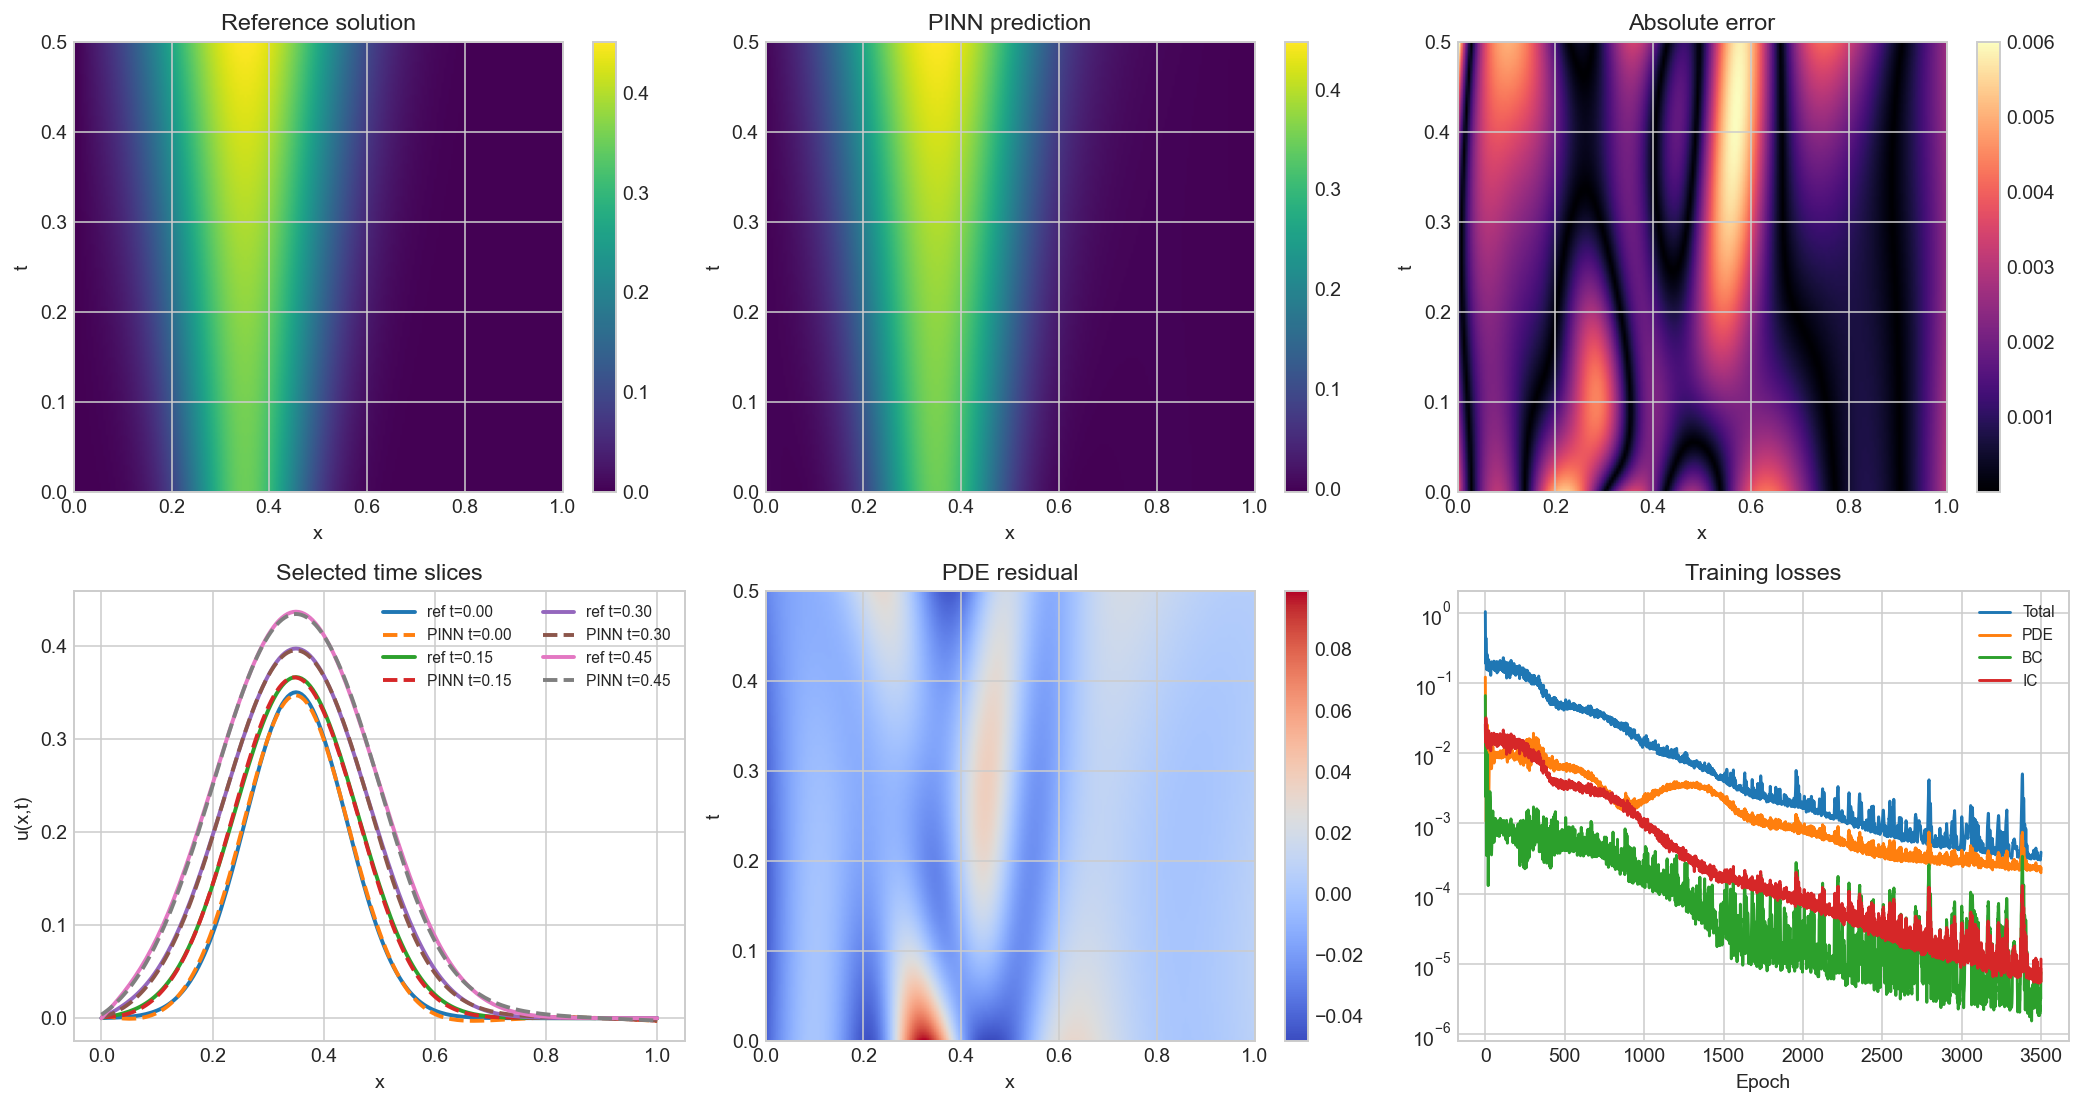

Mean absolute error: 1.710e-03
Max absolute error: 6.002e-03


In [4]:
x_plot = np.linspace(0.0, 1.0, 201)
t_plot = np.linspace(0.0, T_FINAL, 151)
XX, TT = np.meshgrid(x_plot, t_plot)
with torch.no_grad():
    x_tensor = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=device)
    t_tensor = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=device)
    u_pred = model(x_tensor, t_tensor).detach().cpu().numpy().reshape(TT.shape)

ref_interp = RegularGridInterpolator((T_GRID, X), u_ref)
u_ref_plot = ref_interp(np.column_stack([TT.reshape(-1), XX.reshape(-1)])).reshape(TT.shape)
abs_error = np.abs(u_pred - u_ref_plot)

x_res = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=device, requires_grad=True)
t_res = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=device, requires_grad=True)
_, residual_grid = fisher_terms(model, x_res, t_res)
residual_grid = residual_grid.detach().cpu().numpy().reshape(TT.shape)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
im0 = axes[0, 0].imshow(u_ref_plot, origin="lower", aspect="auto", extent=[0, 1, 0, T_FINAL], cmap="viridis")
axes[0, 0].set_title("Reference solution")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("t")
fig.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(u_pred, origin="lower", aspect="auto", extent=[0, 1, 0, T_FINAL], cmap="viridis")
axes[0, 1].set_title("PINN prediction")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("t")
fig.colorbar(im1, ax=axes[0, 1])

im2 = axes[0, 2].imshow(abs_error, origin="lower", aspect="auto", extent=[0, 1, 0, T_FINAL], cmap="magma")
axes[0, 2].set_title("Absolute error")
axes[0, 2].set_xlabel("x")
axes[0, 2].set_ylabel("t")
fig.colorbar(im2, ax=axes[0, 2])

slice_times = [0.0, 0.15, 0.30, 0.45]
for t_sel in slice_times:
    idx = np.argmin(np.abs(t_plot - t_sel))
    axes[1, 0].plot(x_plot, u_ref_plot[idx], linewidth=2, label=f"ref t={t_plot[idx]:.2f}")
    axes[1, 0].plot(x_plot, u_pred[idx], "--", linewidth=2, label=f"PINN t={t_plot[idx]:.2f}")
axes[1, 0].set_title("Selected time slices")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("u(x,t)")
axes[1, 0].legend(ncol=2, fontsize=8)

im3 = axes[1, 1].imshow(residual_grid, origin="lower", aspect="auto", extent=[0, 1, 0, T_FINAL], cmap="coolwarm")
axes[1, 1].set_title("PDE residual")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("t")
fig.colorbar(im3, ax=axes[1, 1])

axes[1, 2].plot(history["total"], label="Total")
axes[1, 2].plot(history["pde"], label="PDE")
axes[1, 2].plot(history["bc"], label="BC")
axes[1, 2].plot(history["ic"], label="IC")
axes[1, 2].set_yscale("log")
axes[1, 2].set_title("Training losses")
axes[1, 2].set_xlabel("Epoch")
axes[1, 2].legend(fontsize=8)

savefig(fig, "reaction_diffusion_summary.png")
plt.show()

print(f"Mean absolute error: {abs_error.mean():.3e}")
print(f"Max absolute error: {abs_error.max():.3e}")

## Key takeaway

The Fisher-KPP equation is a direct nonlinear PDE solve in space-time, which is exactly the setting where PINNs are conceptually natural. The method can learn a smooth reaction-diffusion field without introducing an artificial optimal-control layer.
